<a href="https://colab.research.google.com/github/mohanishmulay/Superkart/blob/main/SuperKartPricePrediction_Mohanish_Mulay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Objective and data dictionary

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm, not just to build a predictive model based on historical sales data but also to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

**Data Dictionary**

1. Product_Id: Unique identifier of each product, each identifier having two

2. letters at the beginning, followed by a number

3. Product_Weight: Weight of each product

4. Product_Sugar_Content: Sugar content of each product, like low sugar, regular, and no sugar

5. Product_Allocated_Area: Ratio of the allocated display area of each product to the total display area of all the products in a store

6. Product_Type: Broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others

7. Product_MRP: Maximum retail price of each product

8. Store_Id: Unique identifier of each store

9. Store_Establishment_Year: Year in which the store was established

10. Store_Size: Size of the store, depending on sq. feet, like high, medium, and low

11. Store_Location_City_Type: Type of city in which the store is located, like Tier 1, Tier 2, and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than that of its Tier 2 and Tier 3 counterparts

12. Store_Type: Type of store depending on the products that are being sold there, like Departmental Store, Supermarket Type 1, Supermarket Type 2, and Food Mart

13. Product_Store_Sales_Total: Total revenue generated by the sale of that pa rticular product in that particular store

##Installing and importing necessary files

In [2]:
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 35.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 1.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency co

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi
import pickle

##Loading the dataset

In [4]:
df = pd.read_csv('/content/sample_data/SuperKart.csv')

##Data Overview

In [5]:
df.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [7]:
df.describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


In [8]:
df.nunique()

,0
Product_Id,8763
Product_Weight,1113
Product_Sugar_Content,4
Product_Allocated_Area,228
Product_Type,16
Product_MRP,6100
Store_Id,4
Store_Establishment_Year,4
Store_Size,3
Store_Location_City_Type,3


In [9]:
df.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [10]:
df.shape

(8763, 12)

In [11]:
df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [12]:
numcols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
catcols = ['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

##Exploratory Data Analysis (EDA)

**Univariate Analysis**

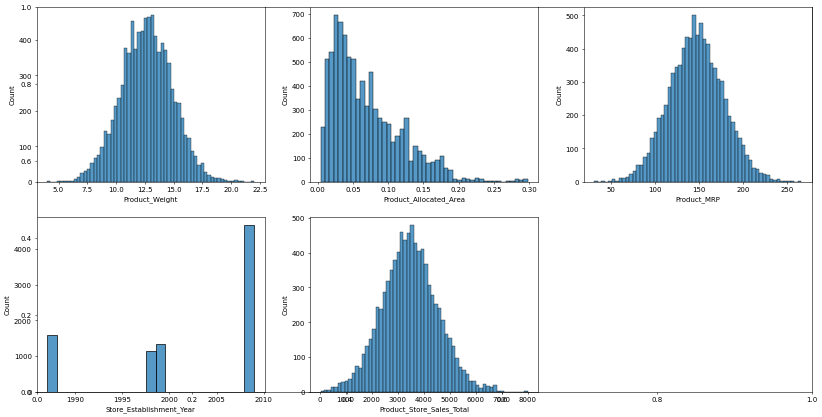

In [13]:
fig, ax = plt.subplots(figsize = (20,10) , dpi = 50)
for i in range(0,len(numcols)):
    plt.subplot(2 , 3 , i+1)
    sns.histplot(df[numcols[i]])
    plt.xlabel(numcols[i])

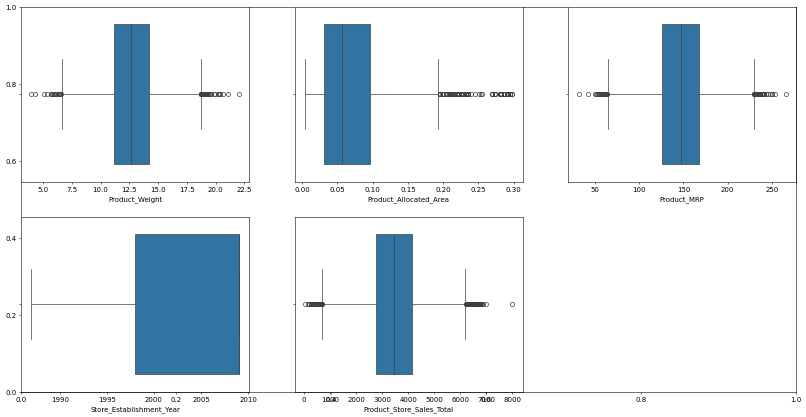

In [14]:
fig, ax = plt.subplots(figsize = (20,10), dpi = 50)
for i in range(0,len(numcols)):
    plt.subplot(2 , 3 , i+1)
    sns.boxplot(x = df[numcols[i]]);

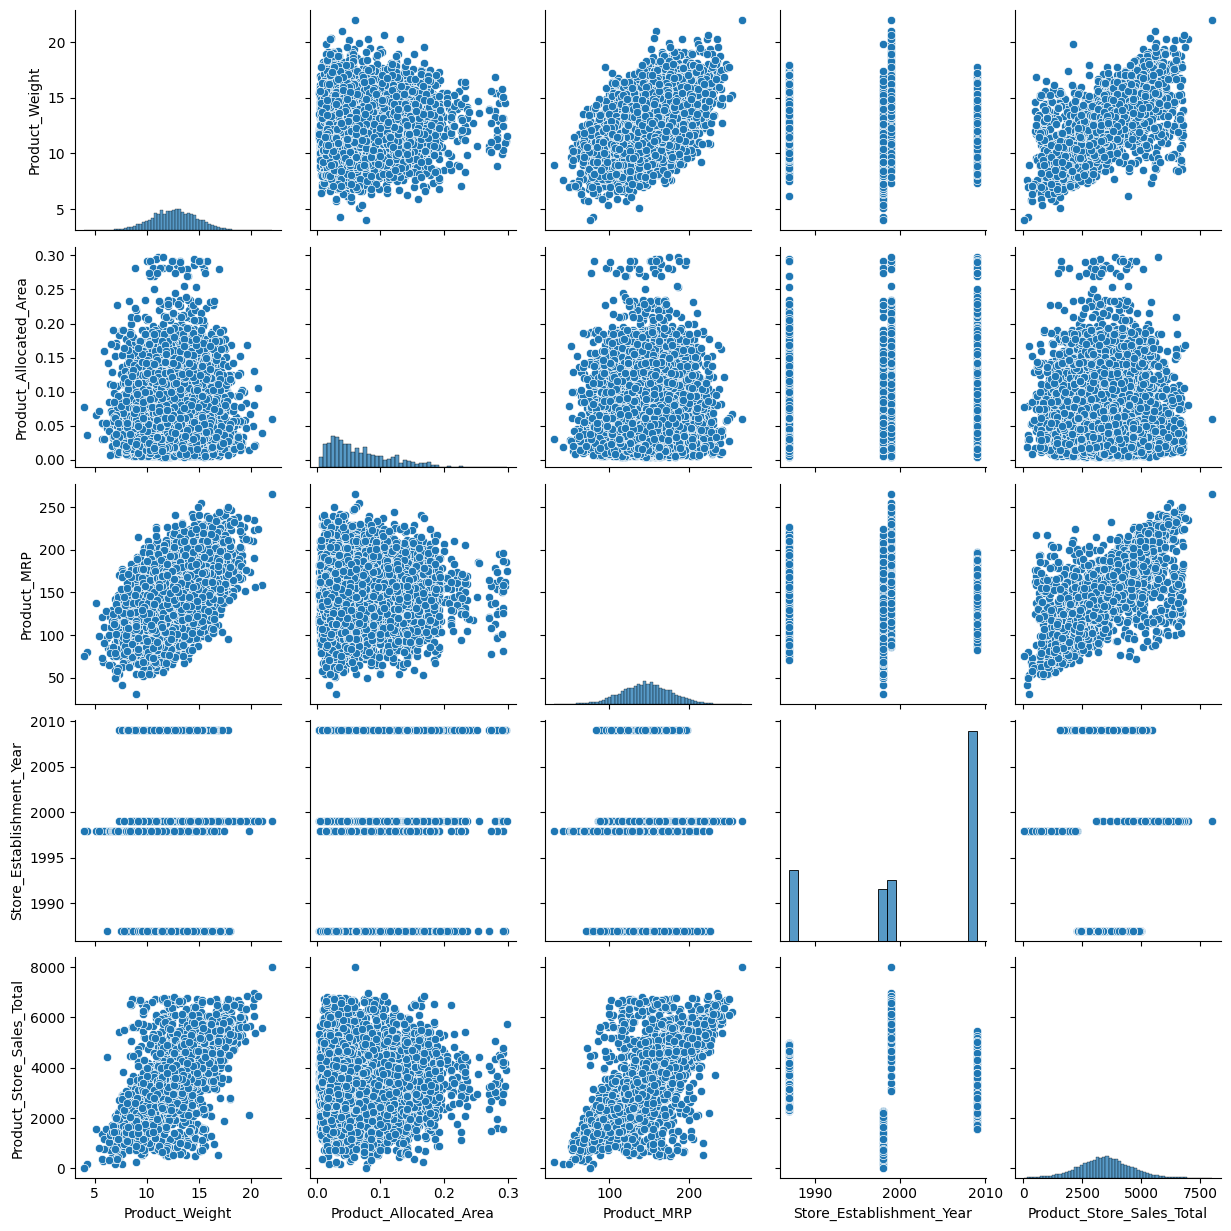

In [15]:
sns.pairplot(df)
plt.show()

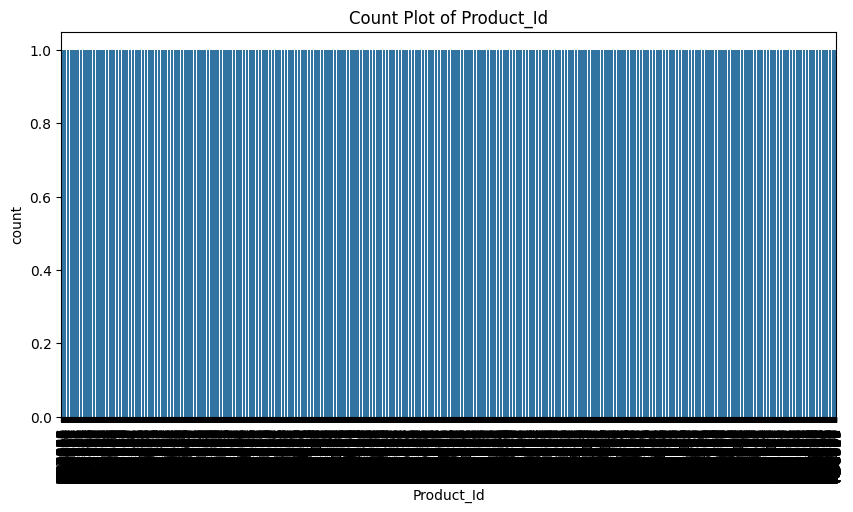

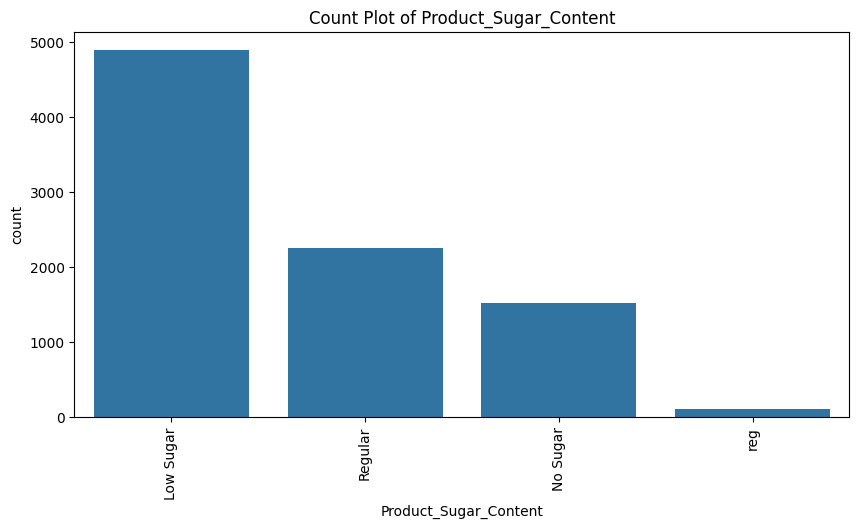

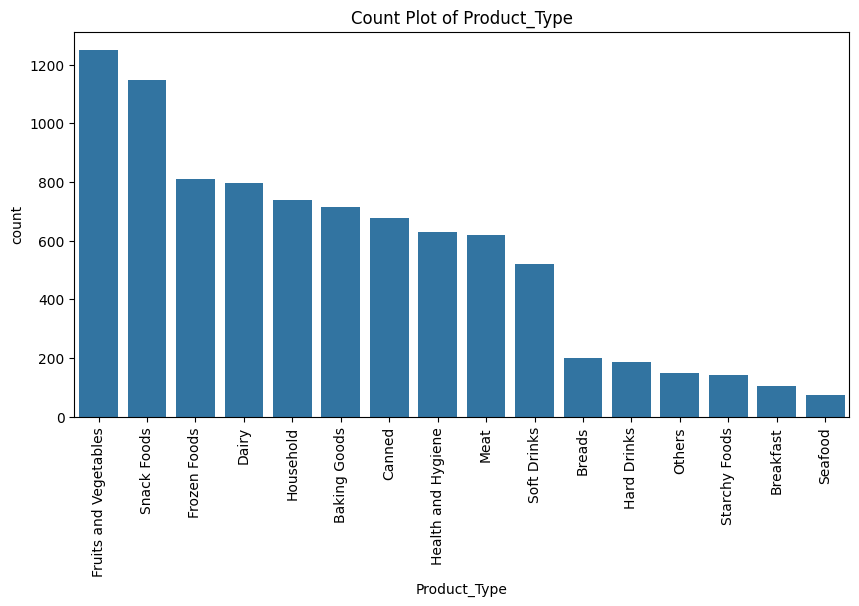

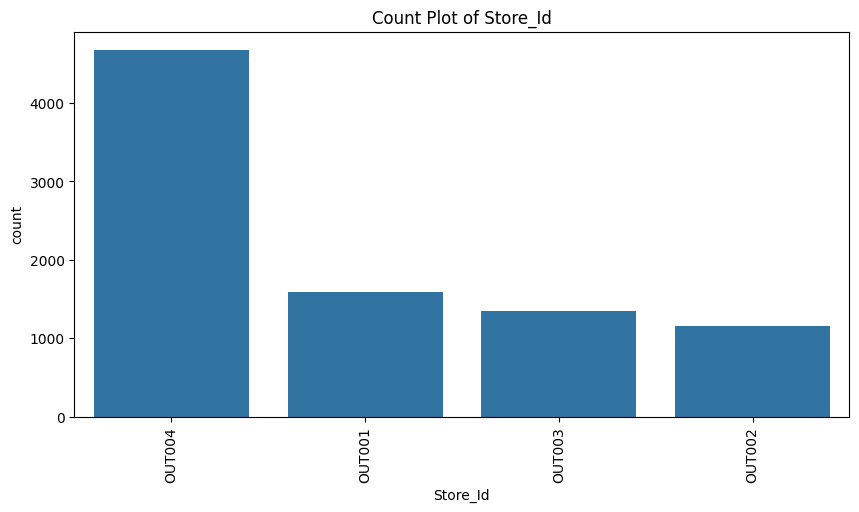

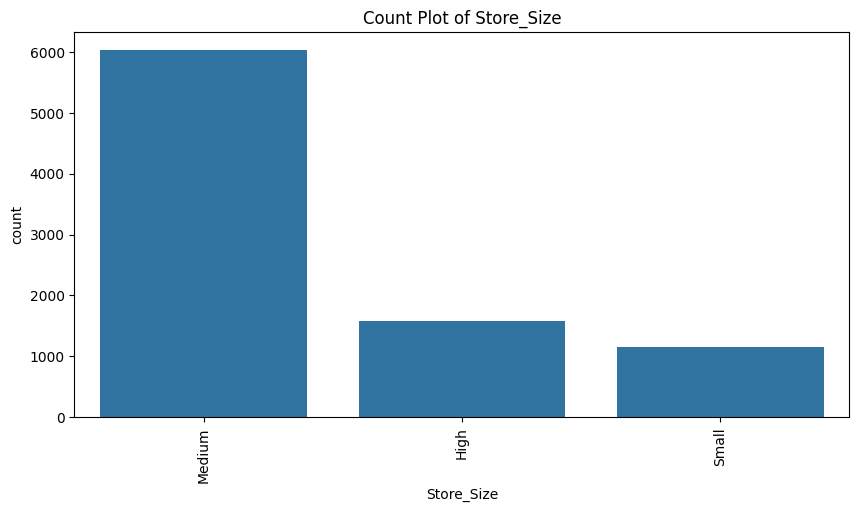

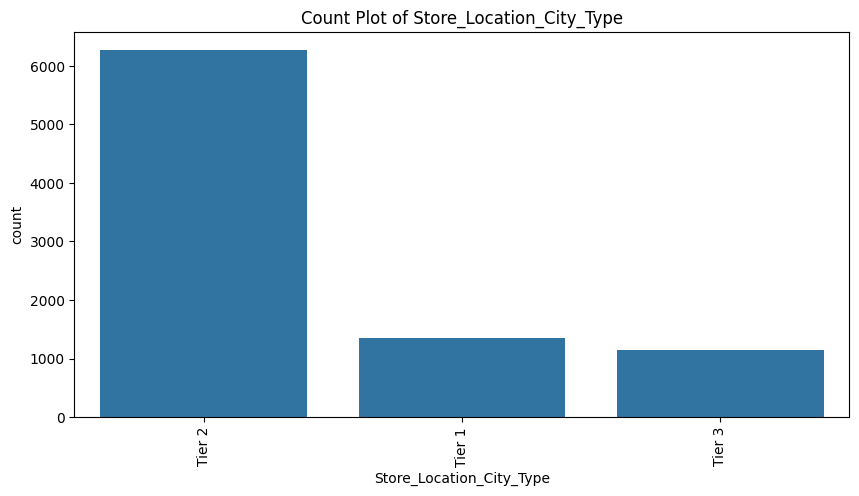

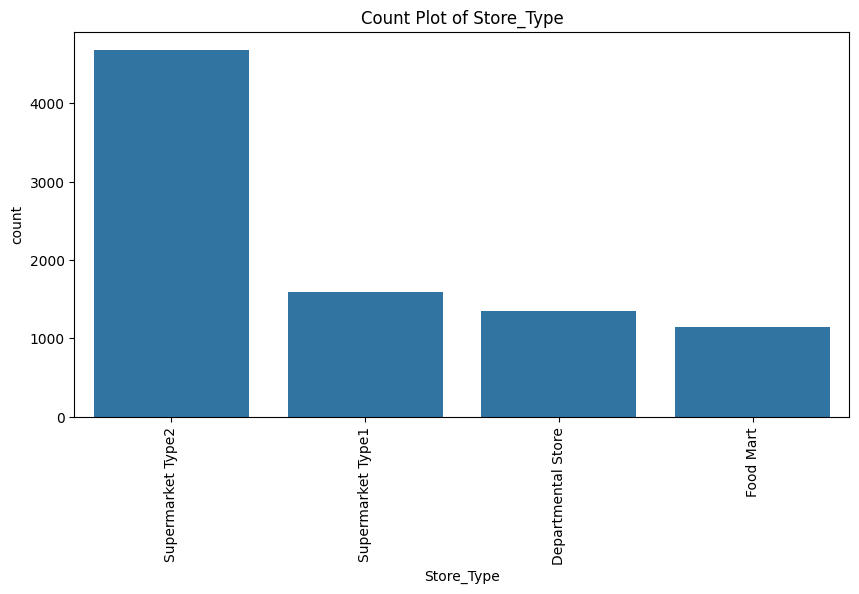

In [16]:
for col in catcols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.xlabel(col)
    plt.title(f'Count Plot of {col}')

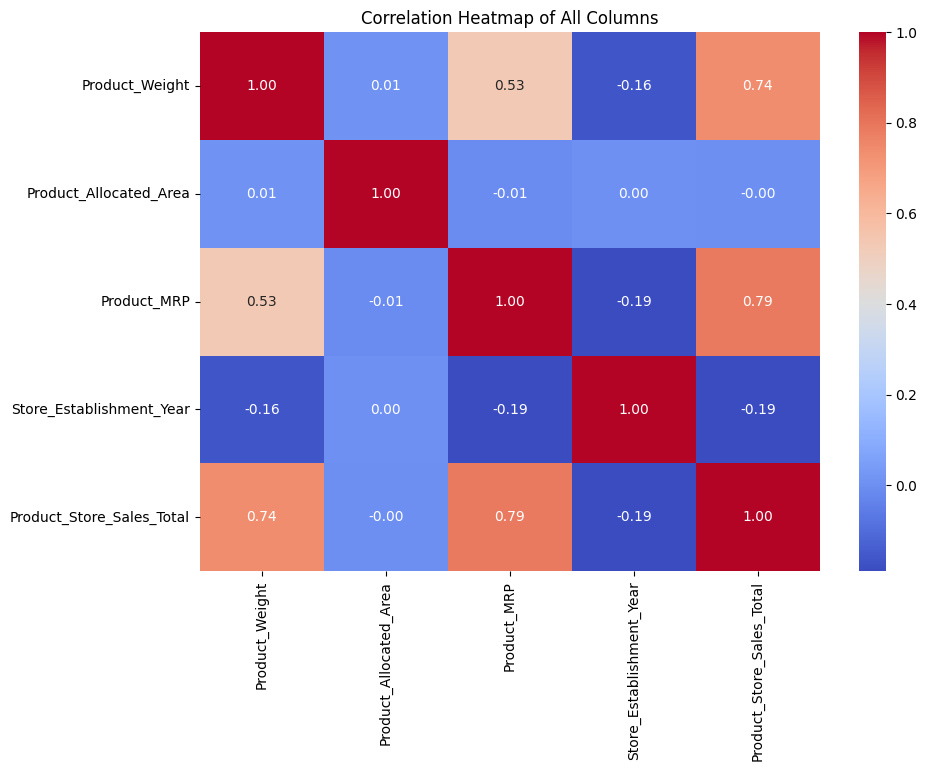

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numcols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Columns')
plt.show()

**Bivariate Analysis**

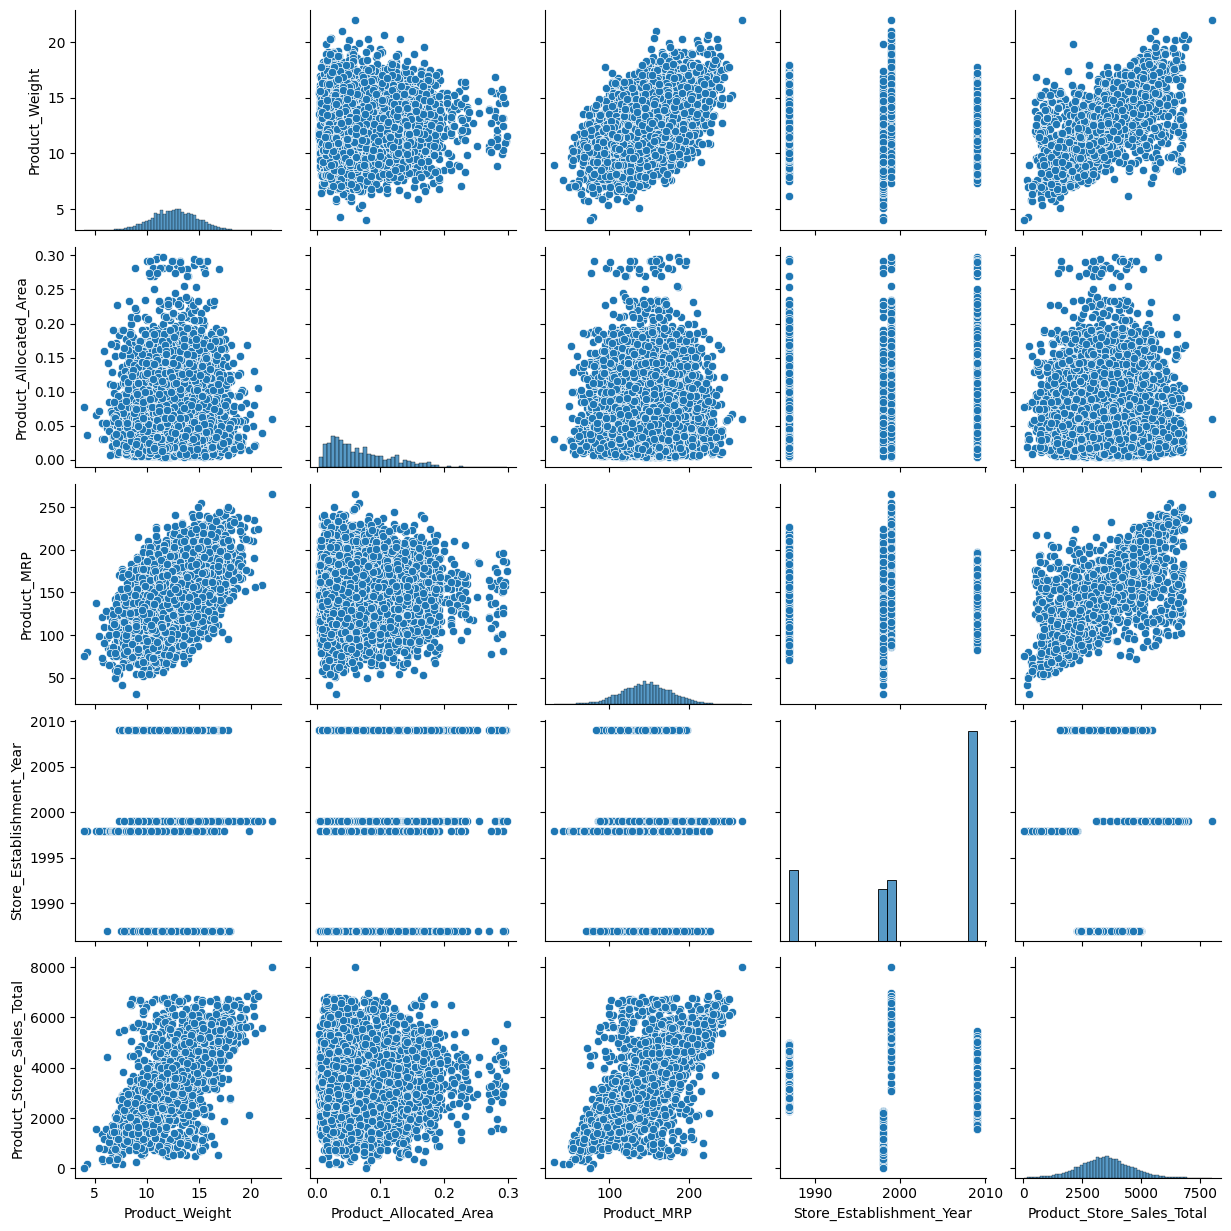

In [18]:
sns.pairplot(df[numcols])
plt.show()

In [19]:
correlation_matrix = df[numcols].corr()
print(correlation_matrix)

                           Product_Weight  Product_Allocated_Area  \
Product_Weight                   1.000000                0.014754   
Product_Allocated_Area           0.014754                1.000000   
Product_MRP                      0.532716               -0.009508   
Store_Establishment_Year        -0.161907                0.004467   
Product_Store_Sales_Total        0.737955               -0.000933   

                           Product_MRP  Store_Establishment_Year  \
Product_Weight                0.532716                 -0.161907   
Product_Allocated_Area       -0.009508                  0.004467   
Product_MRP                   1.000000                 -0.189357   
Store_Establishment_Year     -0.189357                  1.000000   
Product_Store_Sales_Total     0.787989                 -0.185027   

                           Product_Store_Sales_Total  
Product_Weight                              0.737955  
Product_Allocated_Area                     -0.000933  
Product_MRP

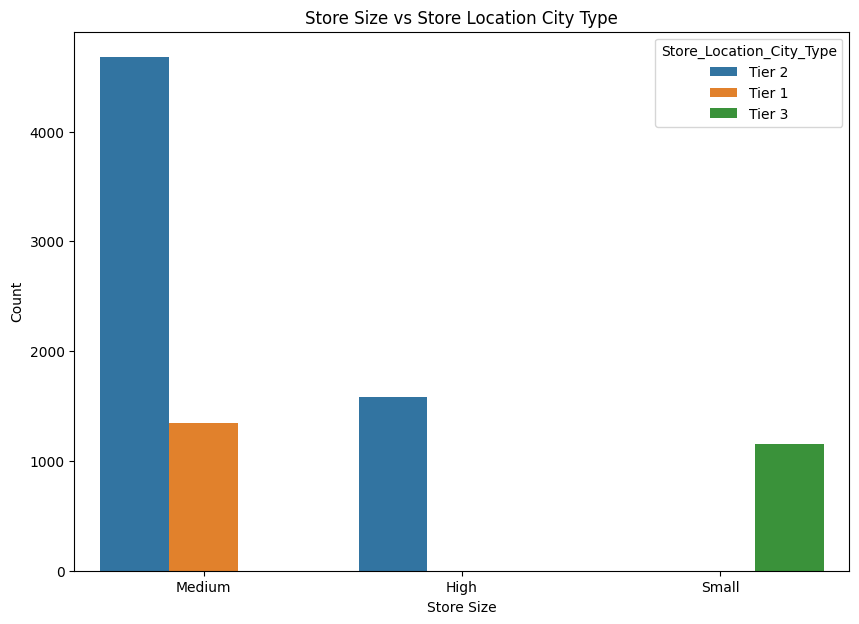

In [20]:
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x= 'Store_Size', hue='Store_Location_City_Type')
plt.title('Store Size vs Store Location City Type')
plt.xlabel('Store Size')
plt.ylabel('Count')
plt.show()

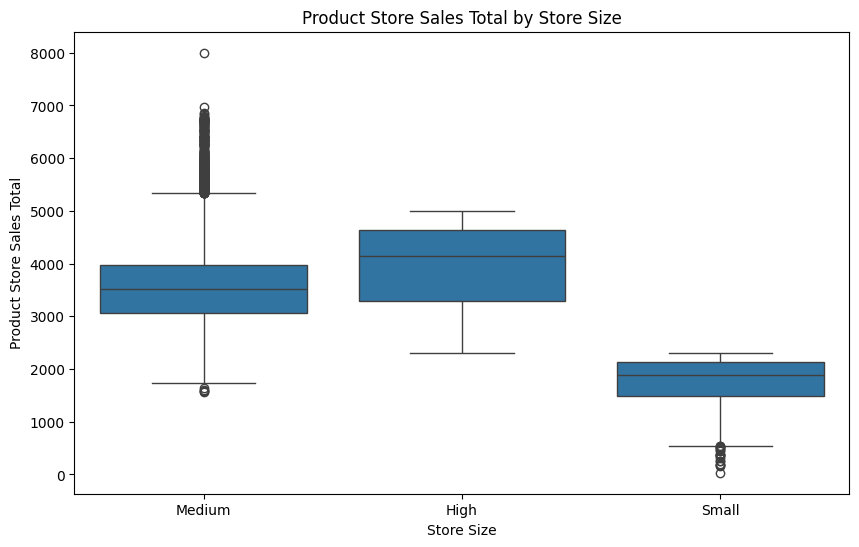

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Store_Size', y='Product_Store_Sales_Total')
plt.title('Product Store Sales Total by Store Size')
plt.xlabel('Store Size')
plt.ylabel('Product Store Sales Total')
plt.show()

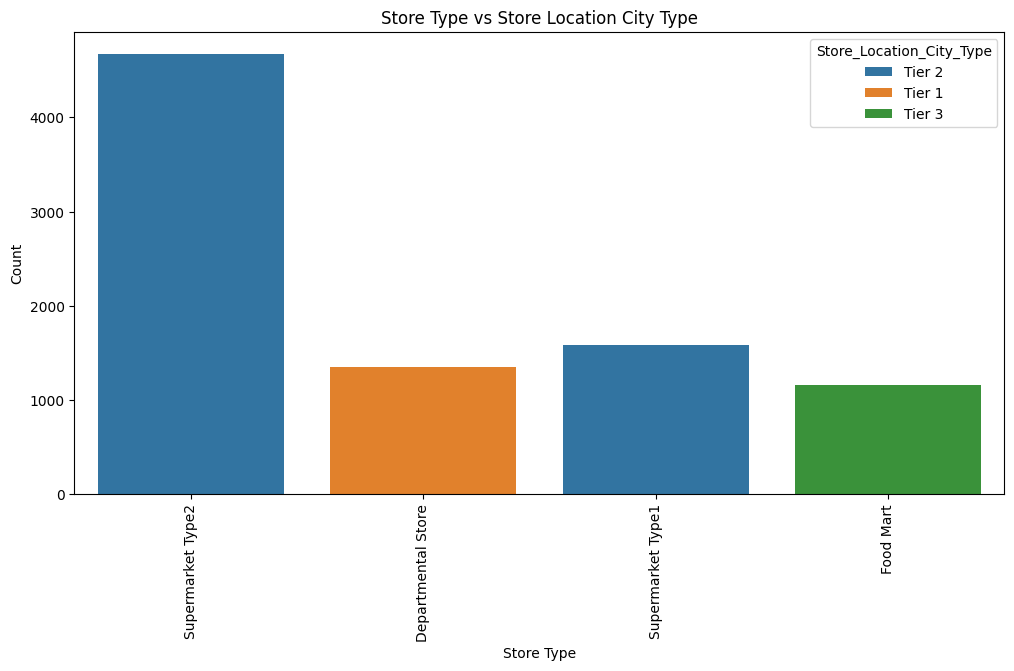

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Store_Type', hue='Store_Location_City_Type')
plt.title('Store Type vs Store Location City Type')
plt.xlabel('Store Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()



*   Supermarket Type 2 has most entries (over 4000)
*   Food Mart has least entries (around 1000-1100)



##Data Prepocessing

In [23]:
# Separate features (X) and target (y)
X = df.drop('Product_Store_Sales_Total', axis=1)
y = df['Product_Store_Sales_Total']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (6572, 11)
Testing set shape: (2191, 11)


In [24]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [25]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Instantiate OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform on training data
X_train_encoded = ohe.fit_transform(X_train[categorical_cols])

# Transform testing data
X_test_encoded = ohe.transform(X_test[categorical_cols])

# Convert encoded arrays to DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

# Identify numerical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Concatenate numerical and encoded categorical columns
X_train_processed = pd.concat([X_train[numerical_cols], X_train_encoded_df], axis=1)
X_test_processed = pd.concat([X_test[numerical_cols], X_test_encoded_df], axis=1)

# Display the first few rows of the processed dataframes
display(X_train_processed.head())
display(X_test_processed.head())

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Id_DR1006,Product_Id_DR1011,Product_Id_DR1075,Product_Id_DR1086,Product_Id_DR1091,Product_Id_DR1112,Product_Id_DR1130,Product_Id_DR1139,Product_Id_DR1157,Product_Id_DR1177,Product_Id_DR1185,Product_Id_DR12,Product_Id_DR1204,Product_Id_DR121,Product_Id_DR1235,Product_Id_DR124,Product_Id_DR1258,Product_Id_DR1269,Product_Id_DR1273,Product_Id_DR1292,Product_Id_DR1303,Product_Id_DR131,Product_Id_DR1313,Product_Id_DR1346,Product_Id_DR1373,Product_Id_DR139,Product_Id_DR1408,Product_Id_DR1426,Product_Id_DR1427,Product_Id_DR1429,Product_Id_DR1452,Product_Id_DR1467,Product_Id_DR1469,Product_Id_DR1493,Product_Id_DR1501,Product_Id_DR1514,Product_Id_DR153,Product_Id_DR1566,Product_Id_DR159,Product_Id_DR1590,Product_Id_DR1593,Product_Id_DR1599,Product_Id_DR160,Product_Id_DR1604,Product_Id_DR1617,Product_Id_DR1659,Product_Id_DR1660,Product_Id_DR1666,Product_Id_DR1676,Product_Id_DR1678,Product_Id_DR1690,Product_Id_DR1691,Product_Id_DR1694,Product_Id_DR1715,Product_Id_DR1725,Product_Id_DR1771,Product_Id_DR1777,Product_Id_DR1785,Product_Id_DR1786,Product_Id_DR1798,Product_Id_DR1834,Product_Id_DR1881,Product_Id_DR1883,Product_Id_DR1894,Product_Id_DR1910,Product_Id_DR1920,Product_Id_DR1957,Product_Id_DR2009,Product_Id_DR2026,Product_Id_DR2032,Product_Id_DR2049,Product_Id_DR2055,Product_Id_DR2074,Product_Id_DR2078,Product_Id_DR2103,Product_Id_DR2104,Product_Id_DR2126,Product_Id_DR2135,Product_Id_DR2156,Product_Id_DR2161,Product_Id_DR217,Product_Id_DR2183,Product_Id_DR2201,Product_Id_DR2222,Product_Id_DR2228,Product_Id_DR2236,Product_Id_DR2268,Product_Id_DR2281,Product_Id_DR2290,Product_Id_DR2350,Product_Id_DR2356,Product_Id_DR2364,Product_Id_DR2373,Product_Id_DR2375,Product_Id_DR2390,Product_Id_DR2392,Product_Id_DR2400,Product_Id_DR2421,Product_Id_DR2430,Product_Id_DR2510,Product_Id_DR2519,Product_Id_DR2522,Product_Id_DR2568,Product_Id_DR260,Product_Id_DR2605,Product_Id_DR2608,Product_Id_DR2699,Product_Id_DR2704,Product_Id_DR2706,Product_Id_DR2733,Product_Id_DR2750,Product_Id_DR2786,Product_Id_DR2804,Product_Id_DR2830,Product_Id_DR2860,Product_Id_DR2863,Product_Id_DR2887,Product_Id_DR2892,Product_Id_DR2896,Product_Id_DR2897,Product_Id_DR2901,Product_Id_DR2947,Product_Id_DR2964,Product_Id_DR2975,Product_Id_DR2978,Product_Id_DR2998,Product_Id_DR3,Product_Id_DR3012,Product_Id_DR3026,Product_Id_DR3027,Product_Id_DR3050,Product_Id_DR3070,Product_Id_DR3082,Product_Id_DR3083,Product_Id_DR3096,Product_Id_DR3104,Product_Id_DR3108,Product_Id_DR3118,Product_Id_DR3127,Product_Id_DR3159,Product_Id_DR3161,Product_Id_DR3210,Product_Id_DR3220,Product_Id_DR3235,Product_Id_DR325,Product_Id_DR3252,Product_Id_DR3293,Product_Id_DR3298,Product_Id_DR332,Product_Id_DR3327,Product_Id_DR3370,Product_Id_DR3382,Product_Id_DR3395,Product_Id_DR3415,Product_Id_DR3443,Product_Id_DR3444,Product_Id_DR3447,Product_Id_DR3454,Product_Id_DR3456,Product_Id_DR3464,Product_Id_DR3476,Product_Id_DR3489,Product_Id_DR3506,Product_Id_DR3512,Product_Id_DR3520,Product_Id_DR353,Product_Id_DR3533,Product_Id_DR3573,Product_Id_DR3578,Product_Id_DR3580,Product_Id_DR3582,Product_Id_DR3676,Product_Id_DR3678,Product_Id_DR368,Product_Id_DR3683,Product_Id_DR371,Product_Id_DR3719,Product_Id_DR3732,Product_Id_DR3737,Product_Id_DR3745,Product_Id_DR3777,Product_Id_DR3787,Product_Id_DR3801,Product_Id_DR3802,Product_Id_DR3821,Product_Id_DR3822,Product_Id_DR3825,Product_Id_DR3844,Product_Id_DR3850,Product_Id_DR3877,Product_Id_DR3912,Product_Id_DR3914,Product_Id_DR3915,Product_Id_DR3952,Product_Id_DR3959,Product_Id_DR3999,Product_Id_DR4015,Product_Id_DR4017,Product_Id_DR4048,Product_Id_DR4069,Product_Id_DR407,Product_Id_DR4091,Product_Id_DR4116,Product_Id_DR4163,Product_Id_DR4182,Product_Id_DR4187,Product_Id_DR4188,Product_Id_DR4194,Product_Id_DR421,Product_Id_DR4213,Product_Id_DR4234,Product_Id_DR4250,Product_Id_DR4259,Product_Id_DR426,Product_Id_DR4265,Product_Id_DR4278,Product_Id_DR4291,Product_Id_DR4311,Product_Id_DR4319,Prod

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Id_DR1006,Product_Id_DR1011,Product_Id_DR1075,Product_Id_DR1086,Product_Id_DR1091,Product_Id_DR1112,Product_Id_DR1130,Product_Id_DR1139,Product_Id_DR1157,Product_Id_DR1177,Product_Id_DR1185,Product_Id_DR12,Product_Id_DR1204,Product_Id_DR121,Product_Id_DR1235,Product_Id_DR124,Product_Id_DR1258,Product_Id_DR1269,Product_Id_DR1273,Product_Id_DR1292,Product_Id_DR1303,Product_Id_DR131,Product_Id_DR1313,Product_Id_DR1346,Product_Id_DR1373,Product_Id_DR139,Product_Id_DR1408,Product_Id_DR1426,Product_Id_DR1427,Product_Id_DR1429,Product_Id_DR1452,Product_Id_DR1467,Product_Id_DR1469,Product_Id_DR1493,Product_Id_DR1501,Product_Id_DR1514,Product_Id_DR153,Product_Id_DR1566,Product_Id_DR159,Product_Id_DR1590,Product_Id_DR1593,Product_Id_DR1599,Product_Id_DR160,Product_Id_DR1604,Product_Id_DR1617,Product_Id_DR1659,Product_Id_DR1660,Product_Id_DR1666,Product_Id_DR1676,Product_Id_DR1678,Product_Id_DR1690,Product_Id_DR1691,Product_Id_DR1694,Product_Id_DR1715,Product_Id_DR1725,Product_Id_DR1771,Product_Id_DR1777,Product_Id_DR1785,Product_Id_DR1786,Product_Id_DR1798,Product_Id_DR1834,Product_Id_DR1881,Product_Id_DR1883,Product_Id_DR1894,Product_Id_DR1910,Product_Id_DR1920,Product_Id_DR1957,Product_Id_DR2009,Product_Id_DR2026,Product_Id_DR2032,Product_Id_DR2049,Product_Id_DR2055,Product_Id_DR2074,Product_Id_DR2078,Product_Id_DR2103,Product_Id_DR2104,Product_Id_DR2126,Product_Id_DR2135,Product_Id_DR2156,Product_Id_DR2161,Product_Id_DR217,Product_Id_DR2183,Product_Id_DR2201,Product_Id_DR2222,Product_Id_DR2228,Product_Id_DR2236,Product_Id_DR2268,Product_Id_DR2281,Product_Id_DR2290,Product_Id_DR2350,Product_Id_DR2356,Product_Id_DR2364,Product_Id_DR2373,Product_Id_DR2375,Product_Id_DR2390,Product_Id_DR2392,Product_Id_DR2400,Product_Id_DR2421,Product_Id_DR2430,Product_Id_DR2510,Product_Id_DR2519,Product_Id_DR2522,Product_Id_DR2568,Product_Id_DR260,Product_Id_DR2605,Product_Id_DR2608,Product_Id_DR2699,Product_Id_DR2704,Product_Id_DR2706,Product_Id_DR2733,Product_Id_DR2750,Product_Id_DR2786,Product_Id_DR2804,Product_Id_DR2830,Product_Id_DR2860,Product_Id_DR2863,Product_Id_DR2887,Product_Id_DR2892,Product_Id_DR2896,Product_Id_DR2897,Product_Id_DR2901,Product_Id_DR2947,Product_Id_DR2964,Product_Id_DR2975,Product_Id_DR2978,Product_Id_DR2998,Product_Id_DR3,Product_Id_DR3012,Product_Id_DR3026,Product_Id_DR3027,Product_Id_DR3050,Product_Id_DR3070,Product_Id_DR3082,Product_Id_DR3083,Product_Id_DR3096,Product_Id_DR3104,Product_Id_DR3108,Product_Id_DR3118,Product_Id_DR3127,Product_Id_DR3159,Product_Id_DR3161,Product_Id_DR3210,Product_Id_DR3220,Product_Id_DR3235,Product_Id_DR325,Product_Id_DR3252,Product_Id_DR3293,Product_Id_DR3298,Product_Id_DR332,Product_Id_DR3327,Product_Id_DR3370,Product_Id_DR3382,Product_Id_DR3395,Product_Id_DR3415,Product_Id_DR3443,Product_Id_DR3444,Product_Id_DR3447,Product_Id_DR3454,Product_Id_DR3456,Product_Id_DR3464,Product_Id_DR3476,Product_Id_DR3489,Product_Id_DR3506,Product_Id_DR3512,Product_Id_DR3520,Product_Id_DR353,Product_Id_DR3533,Product_Id_DR3573,Product_Id_DR3578,Product_Id_DR3580,Product_Id_DR3582,Product_Id_DR3676,Product_Id_DR3678,Product_Id_DR368,Product_Id_DR3683,Product_Id_DR371,Product_Id_DR3719,Product_Id_DR3732,Product_Id_DR3737,Product_Id_DR3745,Product_Id_DR3777,Product_Id_DR3787,Product_Id_DR3801,Product_Id_DR3802,Product_Id_DR3821,Product_Id_DR3822,Product_Id_DR3825,Product_Id_DR3844,Product_Id_DR3850,Product_Id_DR3877,Product_Id_DR3912,Product_Id_DR3914,Product_Id_DR3915,Product_Id_DR3952,Product_Id_DR3959,Product_Id_DR3999,Product_Id_DR4015,Product_Id_DR4017,Product_Id_DR4048,Product_Id_DR4069,Product_Id_DR407,Product_Id_DR4091,Product_Id_DR4116,Product_Id_DR4163,Product_Id_DR4182,Product_Id_DR4187,Product_Id_DR4188,Product_Id_DR4194,Product_Id_DR421,Product_Id_DR4213,Product_Id_DR4234,Product_Id_DR4250,Product_Id_DR4259,Product_Id_DR426,Product_Id_DR4265,Product_Id_DR4278,Product_Id_DR4291,Product_Id_DR4311,Product_Id_DR4319,Prod

**Decision Tree Regression**

In [26]:
from sklearn.tree import DecisionTreeRegressor

# Instantiate a DecisionTreeRegressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Fit the model to the preprocessed training data
dt_model.fit(X_train_processed, y_train)

DecisionTreeRegressor(random_state=42)

In [27]:
# Make predictions on the test data
y_pred = dt_model.predict(X_test_processed)

In [28]:
# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Print the metrics
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

R-squared: 0.9259
Mean Squared Error (MSE): 85475.8594
Root Mean Squared Error (RMSE): 292.3625
Mean Absolute Error (MAE): 91.5960
Mean Absolute Percentage Error (MAPE): 0.0329


**Random Forest Regression**

In [29]:
# Instantiate a BaggingRegressor model
bagging_model = BaggingRegressor(random_state=42)

# Fit the model to the preprocessed training data
bagging_model.fit(X_train_processed, y_train)

BaggingRegressor(random_state=42)

In [30]:
# Make predictions on the test data using the Bagging Regressor model
y_pred_bagging = bagging_model.predict(X_test_processed)

# Calculate evaluation metrics for the Bagging Regressor model
r2_bagging = r2_score(y_test, y_pred_bagging)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mse_bagging)
mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mape_bagging = mean_absolute_percentage_error(y_test, y_pred_bagging)

# Print the metrics for the Bagging Regressor model
print("Metrics for the Bagging Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_bagging:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_bagging:.4f}")
print(f"Mean Absolute Error (MAE): {mae_bagging:.4f}")
print(f"R-squared (R2) Score: {r2_bagging:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_bagging:.4f}")

Metrics for the Bagging Regressor Model:
Mean Squared Error (MSE): 76006.5508
Root Mean Squared Error (RMSE): 275.6929
Mean Absolute Error (MAE): 82.2845
R-squared (R2) Score: 0.9341
Mean Absolute Percentage Error (MAPE): 0.0311


**Model Performance Comparison, Final Model Selection, and Serialization**

In [31]:
# Create a dictionary to store the performance metrics of each model
model_performance = {
    'Decision Tree Regressor': {
        'R-squared': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    },
    'Bagging Regressor': {
        'R-squared': r2_bagging,
        'MSE': mse_bagging,
        'RMSE': rmse_bagging,
        'MAE': mae_bagging,
        'MAPE': mape_bagging
    }
}

# Convert the dictionary to a pandas DataFrame for easy comparison
performance_df = pd.DataFrame.from_dict(model_performance, orient='index')

# Display the performance comparison
print("Model Performance Comparison:")
display(performance_df)

# Determine the best model based on a chosen metric (e.g., lowest RMSE or highest R-squared)
# For regression, lower RMSE and MAE, and higher R-squared are generally better.
best_model_name_rmse = performance_df['RMSE'].idxmin()
best_model_name_r2 = performance_df['R-squared'].idxmax()

print(f"\nModel with the lowest RMSE: {best_model_name_rmse}")
print(f"Model with the highest R-squared: {best_model_name_r2}")

# You can choose the best model based on the metric most relevant to your problem.
# In this case, both metrics point to the same model.
best_model = None
if best_model_name_rmse == 'Bagging Regressor':
    best_model = bagging_model
else:
    best_model = dt_model

print(f"\nSelected Best Model: {best_model.__class__.__name__}")

Model Performance Comparison:


,R-squared,MSE,RMSE,MAE,MAPE
Decision Tree Regressor,0.925932,85475.859398,292.362548,91.596011,0.032891
Bagging Regressor,0.934138,76006.550837,275.692856,82.284545,0.031088



Model with the lowest RMSE: Bagging Regressor
Model with the highest R-squared: Bagging Regressor

Selected Best Model: BaggingRegressor


In [32]:
# Serialize the best model
joblib.dump(best_model, 'best_model.pkl')

print("Best model serialized successfully as 'best_model.pkl'")

Best model serialized successfully as 'best_model.pkl'


##Deployment - Backend

Flask Web Framework

In [33]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [34]:
%%writefile backend_files/app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np

# Initialize Flask app with a name
app = Flask("Superkart's Sales Revenue Prediction")

# Load the trained sales prediction model and the OneHotEncoder
loaded_model = joblib.load("/content/best_model.pkl")

# Define a route for the home page
@app.get('/')
def home():
    return "Welcome to the Superkart Sales Revenue Prediction API"

# Define an endpoint to predict sales for a single product
@app.post('/v1/predict_sales')
def predict_sales():
    try:
        # Get JSON data from the request
        product_data = request.get_json()

        # Convert the received JSON data into a pandas DataFrame
        input_df = pd.DataFrame([product_data])

        # Preprocess the input data using the same steps applied during training
        # Identify categorical columns
        categorical_cols_input = input_df.select_dtypes(include=['object']).columns

        # Transform the categorical columns using the pre-fitted OneHotEncoder
        input_encoded = ohe.transform(input_df[categorical_cols_input])

        # Convert encoded array to DataFrame
        input_encoded_df = pd.DataFrame(input_encoded, columns=ohe.get_feature_names_out(categorical_cols_input), index=input_df.index)

        # Identify numerical columns
        numerical_cols_input = input_df.select_dtypes(include=np.number).columns

        # Concatenate numerical and encoded categorical columns
        input_processed = pd.concat([input_df[numerical_cols_input], input_encoded_df], axis=1)

        # Ensure the order of columns matches the training data
        X_train_processed_cols = X_train_processed.columns.tolist()
        input_processed = input_processed.reindex(columns=X_train_processed_cols, fill_value=0)

        # Use the loaded_model object to make a prediction
        prediction = loaded_model.predict(input_processed)

        # Convert the prediction result to a JSON-serializable format
        prediction_list = prediction.tolist()

        # Return the prediction as a JSON response
        return jsonify({'predicted_sales': prediction_list[0]}) # Assuming single prediction

    except Exception as e:
        return jsonify({'error': str(e)})

# Define an endpoint to predict sales for a batch of products
@app.post('/v1/predict_sales_batch')
def predict_sales_batch():
    try:
        # Get the uploaded CSV file from the request
        file = request.files['file']

        # Read the file into a DataFrame
        input_data = pd.read_csv(file)

        # Preprocess the batch data
        categorical_cols_input = input_data.select_dtypes(include=['object']).columns
        input_encoded = ohe.transform(input_data[categorical_cols_input])
        input_encoded_df = pd.DataFrame(input_encoded, columns=ohe.get_feature_names_out(categorical_cols_input), index=input_data.index)
        numerical_cols_input = input_data.select_dtypes(include=np.number).columns
        input_processed = pd.concat([input_data[numerical_cols_input], input_encoded_df], axis=1)

        # Ensure the order of columns matches the training data
        X_train_processed_cols = X_train_processed.columns.tolist()
        input_processed = input_processed.reindex(columns=X_train_processed_cols, fill_value=0)

        # Make predictions for the batch data
        predictions = loaded_model.predict(input_processed).tolist()

        # You might want to return predictions along with Product_Id or other identifiers
        # For simplicity, returning just the list of predictions
        return jsonify({'predicted_sales_batch': predictions})

    except Exception as e:
        return jsonify({'error': str(e)})


# Run the Flask app in debug mode
if __name__ == '__main__':
    # To run the app in a production environment, you would use a production-ready WSGI server
    # app.run(debug=True) # Use debug=False in production
    # Running on all interfaces to be accessible externally in Colab
    app.run(host='0.0.0.0', port=5000, debug=True)

Writing backend_files/app.py


**Streamlit for Interactive UI**

In [35]:
%%writefile backend_files/app.py

import streamlit as st
import joblib

# Load the trained model and the OneHotEncoder
@st.cache_resource
def load_resources():
    loaded_model = joblib.load("/content/best_model.pkl")
    # Assuming the OneHotEncoder and the list of columns after preprocessing are saved
    # If not, you would need to save them during the training phase
    # For now, I will assume the OneHotEncoder object and X_train_processed are available
    # If they are not, you would need to load them as well:
    # loaded_ohe = joblib.load("/content/ohe.pkl")
    # processed_cols = joblib.load("/content/processed_cols.pkl")
    return loaded_model # Assuming ohe and X_train_processed are globally available or handled

model = load_resources()

# Streamlit UI for Sales Revenue Prediction
st.title("Superkart's Sales Revenue Prediction")
st.write("This tool predicts Superkart's Sales Revenue based on product and store details.")

st.subheader("Enter the product and store details:")

# Collect user input based on the SuperKart dataset features
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.0)
# Assuming Product_Sugar_Content has specific categories based on EDA
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar", "High Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.05)
# Assuming Product_Type has specific categories based on EDA
Product_Type = st.selectbox("Product Type", ['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Health and Hygiene', 'Snack Foods', 'Meat', 'Household', 'Hard Drinks', 'Fruits and Vegetables', 'Breads', 'Soft Drinks', 'Breakfast', 'Others', 'Starchy Foods', 'Seafood'])
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=150.0)
# Assuming Store_Id has specific categories based on EDA
Store_Id = st.selectbox("Store ID", ['OUT004', 'OUT003', 'OUT001', 'OUT002', 'OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027']) # Added more potential IDs
Store_Establishment_Year = st.number_input("Store Establishment Year", min_value=1900, max_value=2023, value=2000)
# Assuming Store_Size has specific categories based on EDA
Store_Size = st.selectbox("Store Size", ["Medium", "High", "Small"])
# Assuming Store_Location_City_Type has specific categories based on EDA
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
# Assuming Store_Type has specific categories based on EDA
Store_Type = st.selectbox("Store Type", ["Supermarket Type2", "Departmental Store", "Supermarket Type1", "Food Mart"])


# Convert user input into a DataFrame
input_data = pd.DataFrame([{
    'Product_Weight': Product_Weight,
    'Product_Sugar_Content': Product_Sugar_Content,
    'Product_Allocated_Area': Product_Allocated_Area,
    'Product_Type': Product_Type,
    'Product_MRP': Product_MRP,
    'Store_Id': Store_Id,
    'Store_Establishment_Year': Store_Establishment_Year,
    'Store_Size': Store_Size,
    'Store_Location_City_Type': Store_Location_City_Type,
    'Store_Type': Store_Type
}])

# Preprocess the input data using the same steps applied during training
# Identify categorical columns
categorical_cols_input = input_data.select_dtypes(include=['object']).columns

# Transform the categorical columns using the pre-fitted OneHotEncoder
# Assuming 'ohe' is available globally or loaded
input_encoded = ohe.transform(input_data[categorical_cols_input])

# Convert encoded array to DataFrame
input_encoded_df = pd.DataFrame(input_encoded, columns=ohe.get_feature_names_out(categorical_cols_input), index=input_data.index)

# Identify numerical columns
numerical_cols_input = input_data.select_dtypes(include=np.number).columns

# Concatenate numerical and encoded categorical columns
input_processed = pd.concat([input_data[numerical_cols_input], input_encoded_df], axis=1)

# Ensure the order of columns matches the training data
# Assuming X_train_processed is available or its column list is saved
X_train_processed_cols = X_train_processed.columns.tolist()
input_processed = input_processed.reindex(columns=X_train_processed_cols, fill_value=0)


# Predict button
if st.button("Predict Sales Revenue"):
    prediction = model.predict(input_processed)
    st.write(f"The predicted sales revenue is: ${prediction[0]:.2f}")

Overwriting backend_files/app.py


**Dependencies File**

In [36]:
%%writefile /content/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
streamlit==1.43.2

Writing /content/requirements.txt


In [40]:
%%writefile Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy the Streamlit app file, the serialized model, and the requirements file into the container
COPY backend_files/app.py /app/app.py
COPY best_model.pkl /app/best_model.pkl
COPY requirements.txt /app/requirements.txt


# Install Python dependencies listed in requirements.txt
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting Dockerfile
